# RAID — Results Analysis Notebook
Loads saved predictions from Drive and recomputes all metrics (including fixed AUC per model/domain).

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

OUT_DIR = "/content/drive/MyDrive/minor prj temp/raid_results"

# Column names as saved by the benchmark notebook
MODEL_COL  = "model"
DOMAIN_COL = "domain"
LABEL_COL  = "label"
PRED_COL   = "pred"
PROB_COL   = "prob"

print("Setup done v")

Setup done v


## 2. Load Predictions

In [3]:
df = pd.read_csv(f'{OUT_DIR}/predictions.csv')
print(f"Loaded {len(df):,} rows")
print(df.head(3))
print(f"\nColumns: {df.columns.tolist()}")
print(f"Label dist: {df[LABEL_COL].value_counts().to_dict()}")

Loaded 467,985 rows
   model     domain  label  pred      prob
0  human  abstracts      0     1  0.999961
1  human  abstracts      0     1  0.998544
2  human  abstracts      0     1  0.998134

Columns: ['model', 'domain', 'label', 'pred', 'prob']
Label dist: {1: 454614, 0: 13371}


In [4]:
true_labels = df[LABEL_COL].values
preds       = df[PRED_COL].values
probs       = df[PROB_COL].values

## 3. Threshold Tuning

In [5]:
fpr_c, tpr_c, thresholds_c = roc_curve(true_labels, probs)
optimal_idx       = np.argmax(tpr_c - fpr_c)
optimal_threshold = thresholds_c[optimal_idx]
preds_tuned       = (probs >= optimal_threshold).astype(int)

print(f"Mean P(AI) — true Human : {probs[true_labels==0].mean():.4f}")
print(f"Mean P(AI) — true AI    : {probs[true_labels==1].mean():.4f}")
print(f"Optimal threshold       : {optimal_threshold:.4f}")

Mean P(AI) — true Human : 0.5489
Mean P(AI) — true AI    : 0.6001
Optimal threshold       : 0.0001


## 4. Overall Metrics (default vs tuned threshold)

In [6]:
def summarise(y_true, y_pred, y_prob, label=''):
    acc    = accuracy_score(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, average='binary')
    f1_mac = f1_score(y_true, y_pred, average='macro')
    auc    = roc_auc_score(y_true, y_prob)

    # TPR@FPR=5% and TPR@FPR=1%  (official RAID metrics)
    fpr_arr, tpr_arr, _ = roc_curve(y_true, y_prob)
    tpr_at_5  = float(tpr_arr[np.searchsorted(fpr_arr, 0.05)])
    tpr_at_1  = float(tpr_arr[np.searchsorted(fpr_arr, 0.01)])

    print(f"{'='*48}  {label}")
    print(f"  Accuracy       : {acc:.4f}")
    print(f"  F1  (binary)   : {f1:.4f}")
    print(f"  F1  (macro)    : {f1_mac:.4f}")
    print(f"  AUROC          : {auc:.4f}")
    print(f"  TPR@FPR=5%%    : {tpr_at_5:.4f}")
    print(f"  TPR@FPR=1%%    : {tpr_at_1:.4f}")
    print(f"{'='*48}")
    print(classification_report(y_true, y_pred, target_names=['Human','AI']))
    return auc, f1, tpr_at_5, tpr_at_1

print("--- Default threshold (0.5) ---")
auc, f1, tpr5, tpr1 = summarise(true_labels, preds, probs, 'default')

print("\n--- Optimal threshold ---")
auc_t, f1_t, tpr5_t, tpr1_t = summarise(true_labels, preds_tuned, probs, f'threshold={optimal_threshold:.3f}')

--- Default threshold (0.5) ---
================================================  default
  Accuracy       : 0.5960
  F1  (binary)   : 0.7427
  F1  (macro)    : 0.4013
  AUROC          : 0.5416
  TPR@FPR=5%%    : 0.0798
  TPR@FPR=1%%    : 0.0296
              precision    recall  f1-score   support

       Human       0.03      0.45      0.06     13371
          AI       0.97      0.60      0.74    454614

    accuracy                           0.60    467985
   macro avg       0.50      0.53      0.40    467985
weighted avg       0.95      0.60      0.72    467985


--- Optimal threshold ---
================================================  threshold=0.000
  Accuracy       : 0.8537
  F1  (binary)   : 0.9206
  F1  (macro)    : 0.4938
  AUROC          : 0.5416
  TPR@FPR=5%%    : 0.0798
  TPR@FPR=1%%    : 0.0296
              precision    recall  f1-score   support

       Human       0.04      0.18      0.07     13371
          AI       0.97      0.87      0.92    454614

    accuracy  

## 5. Fixed Per-Model / Per-Domain Metrics (correct AUC)

In [7]:
# AUC fix: each AI-model group is evaluated against ALL human rows
# so every slice has both classes present.

human_rows = df[df[LABEL_COL] == 0].copy()

def group_metrics_fixed(g, group_col):
    """For AI-model rows in group g, pair with all human rows to compute AUC."""
    ai_rows = g[g[LABEL_COL] == 1]
    if len(ai_rows) == 0:
        return None  # skip pure-human groups

    slice_ = pd.concat([ai_rows, human_rows])
    auc_val = roc_auc_score(slice_[LABEL_COL], slice_[PROB_COL])

    fpr_s, tpr_s, _ = roc_curve(slice_[LABEL_COL], slice_[PROB_COL])
    tpr5 = float(tpr_s[np.searchsorted(fpr_s, 0.05)])
    tpr1 = float(tpr_s[np.searchsorted(fpr_s, 0.01)])

    return pd.Series({
        'n':           len(g),
        'accuracy':    accuracy_score(g[LABEL_COL], g[PRED_COL]),
        'f1':          f1_score(g[LABEL_COL], g[PRED_COL], average='binary', zero_division=0),
        'auc':         auc_val,
        'tpr@fpr=5%':  tpr5,
        'tpr@fpr=1%':  tpr1,
    })

# Per-model
model_metrics = (
    df[df[MODEL_COL] != 'human']
    .groupby(MODEL_COL, observed=True)
    .apply(lambda g: group_metrics_fixed(g, MODEL_COL))
    .dropna()
    .sort_values('auc', ascending=False)
)

# Per-domain
domain_metrics = (
    df[df[MODEL_COL] != 'human']
    .groupby(DOMAIN_COL, observed=True)
    .apply(lambda g: group_metrics_fixed(g, DOMAIN_COL))
    .dropna()
    .sort_values('auc', ascending=False)
)

print("=== Per-model ===")
print(model_metrics.round(4).to_string())
print("\n=== Per-domain ===")
print(domain_metrics.round(4).to_string())

/tmp/ipykernel_1772/2023751832.py:32: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: group_metrics_fixed(g, MODEL_COL))


=== Per-model ===
                    n  accuracy      f1     auc  tpr@fpr=5%  tpr@fpr=1%
model                                                                  
chatgpt       26742.0    0.8085  0.8941  0.7065      0.2178      0.0948
gpt4          26742.0    0.7787  0.8756  0.6932      0.2165      0.1058
mpt-chat      53484.0    0.7467  0.8550  0.6491      0.1250      0.0421
llama-chat    53484.0    0.7614  0.8645  0.6456      0.1118      0.0399
mistral-chat  53484.0    0.7386  0.8497  0.6407      0.1283      0.0515
cohere-chat   26742.0    0.6247  0.7690  0.5541      0.0618      0.0156
cohere        26742.0    0.6115  0.7590  0.5321      0.0407      0.0089
gpt3          26742.0    0.5194  0.6837  0.4840      0.0293      0.0037
mistral       53484.0    0.4577  0.6280  0.4326      0.0177      0.0023
mpt           53484.0    0.3842  0.5552  0.3876      0.0047      0.0006
gpt2          53484.0    0.3421  0.5098  0.3634      0.0082      0.0009

=== Per-domain ===
                 n  accura

/tmp/ipykernel_1772/2023751832.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: group_metrics_fixed(g, DOMAIN_COL))


## 6. Model × Domain Cross Pivot

In [8]:
records = []
for (mdl, dom), g in df[df[MODEL_COL] != 'human'].groupby([MODEL_COL, DOMAIN_COL], observed=True):
    ai_rows = g[g[LABEL_COL] == 1]
    if len(ai_rows) == 0:
        continue
    slice_ = pd.concat([ai_rows, human_rows])
    fpr_s, tpr_s, _ = roc_curve(slice_[LABEL_COL], slice_[PROB_COL])
    records.append({
        MODEL_COL:    mdl,
        DOMAIN_COL:   dom,
        'n':          len(g),
        'f1':         f1_score(g[LABEL_COL], g[PRED_COL], average='binary', zero_division=0),
        'auc':        roc_auc_score(slice_[LABEL_COL], slice_[PROB_COL]),
        'tpr@fpr=5%': float(tpr_s[np.searchsorted(fpr_s, 0.05)]),
        'tpr@fpr=1%': float(tpr_s[np.searchsorted(fpr_s, 0.01)]),
    })

cross = pd.DataFrame(records)
f1_pivot   = cross.pivot(index=MODEL_COL, columns=DOMAIN_COL, values='f1')
auc_pivot  = cross.pivot(index=MODEL_COL, columns=DOMAIN_COL, values='auc')
tpr5_pivot = cross.pivot(index=MODEL_COL, columns=DOMAIN_COL, values='tpr@fpr=5%')
n_pivot    = cross.pivot(index=MODEL_COL, columns=DOMAIN_COL, values='n').fillna(0).astype(int)

print("=== AUC pivot (Model x Domain) ===")
print(auc_pivot.round(3).to_string())

=== AUC pivot (Model x Domain) ===
domain        abstracts  books   news  poetry  recipes  reddit  reviews   wiki
model                                                                         
chatgpt           0.571  0.913  0.818   0.767    0.562   0.386    0.921  0.813
cohere            0.597  0.676  0.621   0.394    0.502   0.204    0.473  0.762
cohere-chat       0.542  0.631  0.687   0.412    0.523   0.248    0.640  0.789
gpt2              0.404  0.313  0.501   0.218    0.450   0.194    0.271  0.513
gpt3              0.467  0.555  0.624   0.246    0.503   0.212    0.506  0.767
gpt4              0.638  0.906  0.765   0.794    0.453   0.396    0.954  0.761
llama-chat        0.546  0.773  0.769   0.573    0.583   0.372    0.844  0.797
mistral           0.490  0.444  0.583   0.246    0.486   0.186    0.287  0.670
mistral-chat      0.621  0.759  0.790   0.442    0.589   0.326    0.926  0.806
mpt               0.426  0.383  0.487   0.257    0.408   0.207    0.307  0.587
mpt-chat         

## 7. Visualisations

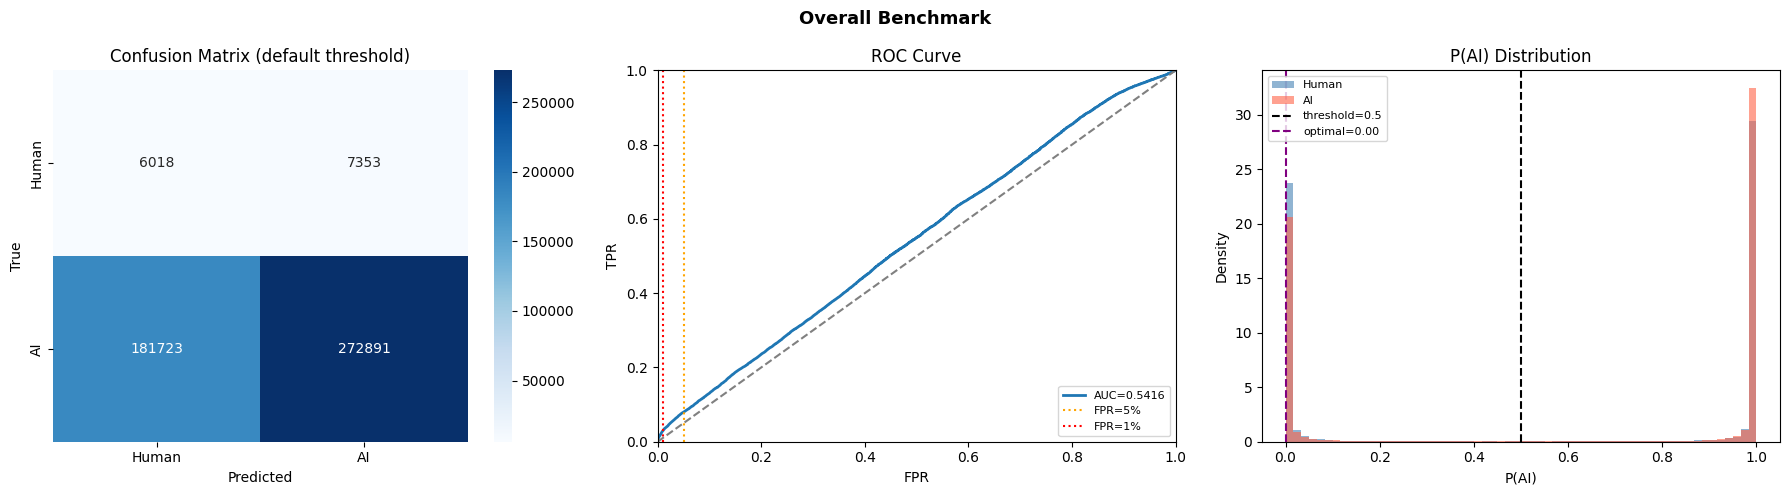

In [9]:
# ── Figure 1: Overall diagnostics ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Overall Benchmark', fontsize=13, fontweight='bold')

cm = confusion_matrix(true_labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human','AI'], yticklabels=['Human','AI'], ax=axes[0])
axes[0].set_title('Confusion Matrix (default threshold)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

fpr_r, tpr_r, _ = roc_curve(true_labels, probs)
axes[1].plot(fpr_r, tpr_r, lw=2, label=f'AUC={auc:.4f}')
axes[1].axvline(0.05, linestyle=':', color='orange', label='FPR=5%')
axes[1].axvline(0.01, linestyle=':', color='red',    label='FPR=1%')
axes[1].plot([0,1],[0,1],'--', color='grey')
axes[1].set_title('ROC Curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(fontsize=8); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)

for lbl, name, color in [(0,'Human','steelblue'),(1,'AI','tomato')]:
    axes[2].hist(probs[true_labels==lbl], bins=60, alpha=0.6,
                 label=name, color=color, density=True)
axes[2].axvline(0.5,               linestyle='--', color='black',  label='threshold=0.5')
axes[2].axvline(optimal_threshold, linestyle='--', color='purple', label=f'optimal={optimal_threshold:.2f}')
axes[2].set_title('P(AI) Distribution'); axes[2].set_xlabel('P(AI)')
axes[2].set_ylabel('Density'); axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/overall_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

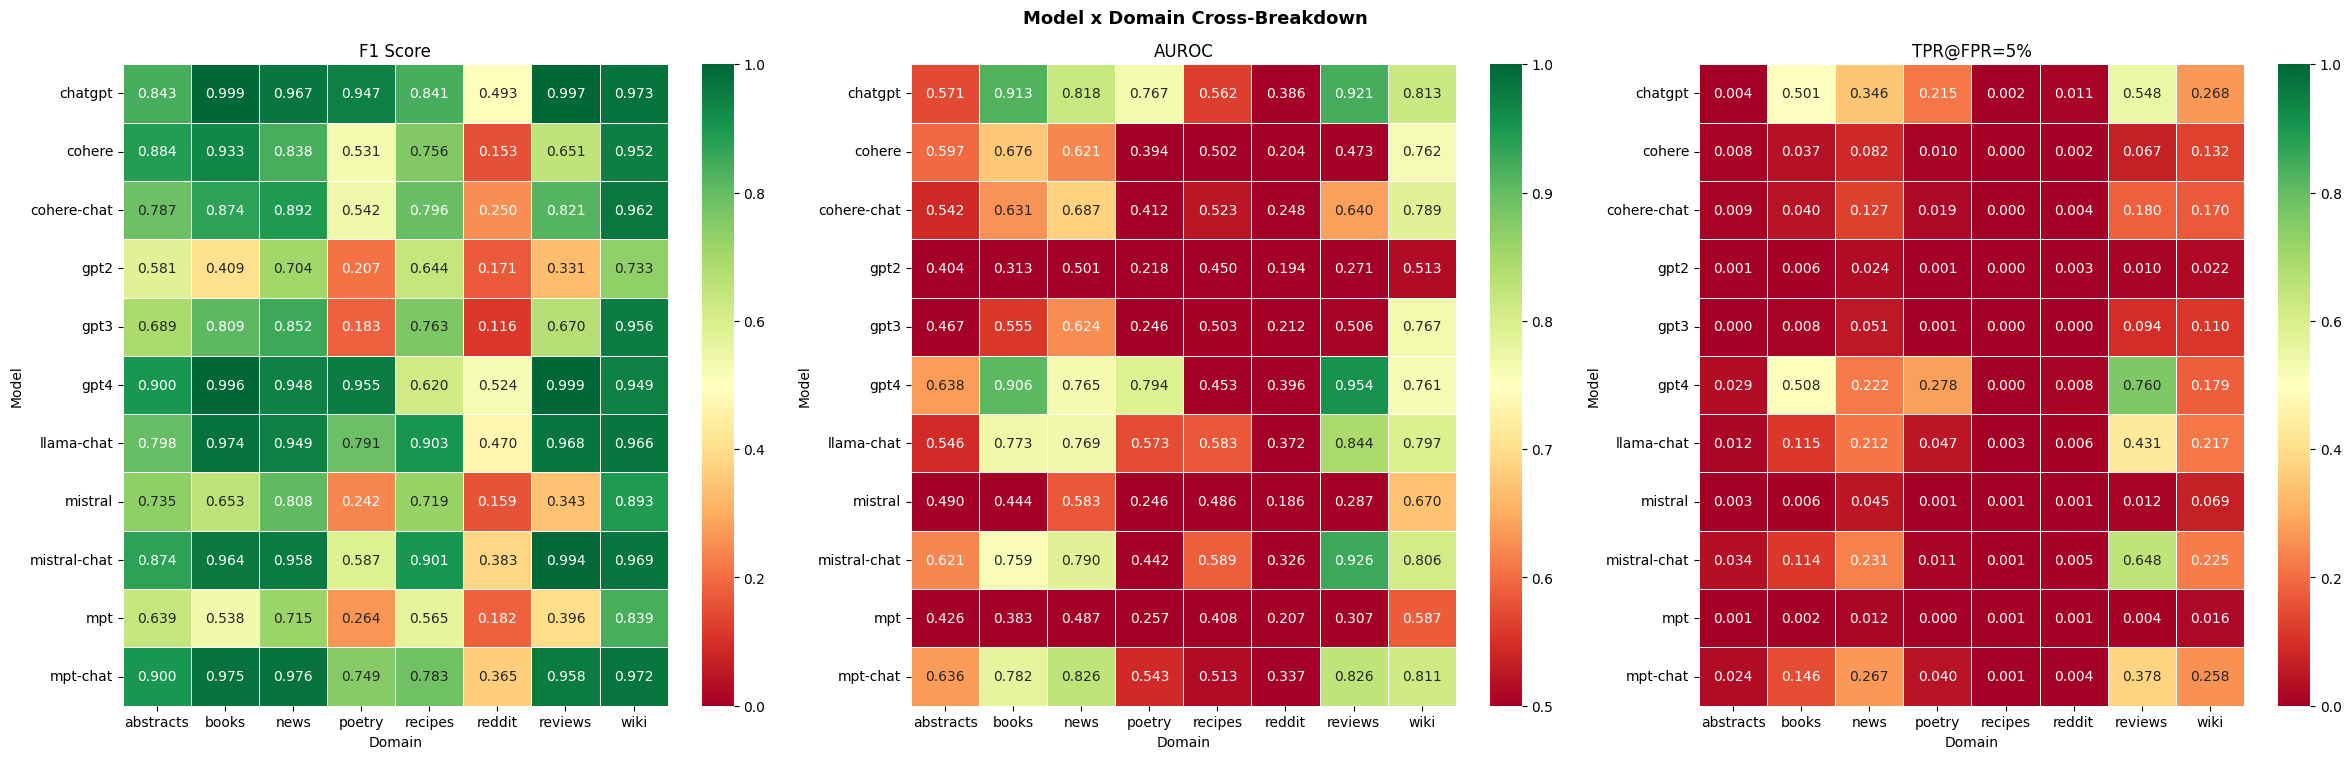

In [10]:
# ── Figure 2: Model x Domain heatmaps ─────────────────────────────────────
nrows = max(6, len(auc_pivot) * 0.7)
fig, axes = plt.subplots(1, 3, figsize=(24, nrows))
fig.suptitle('Model x Domain Cross-Breakdown', fontsize=13, fontweight='bold')

for ax, data, title, vmin in [
    (axes[0], f1_pivot,   'F1 Score',     0.0),
    (axes[1], auc_pivot,  'AUROC',        0.5),
    (axes[2], tpr5_pivot, 'TPR@FPR=5%',  0.0),
]:
    sns.heatmap(data, annot=True, fmt='.3f', cmap='RdYlGn',
                vmin=vmin, vmax=1, linewidths=0.4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Domain'); ax.set_ylabel('Model')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/model_domain_heatmap_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

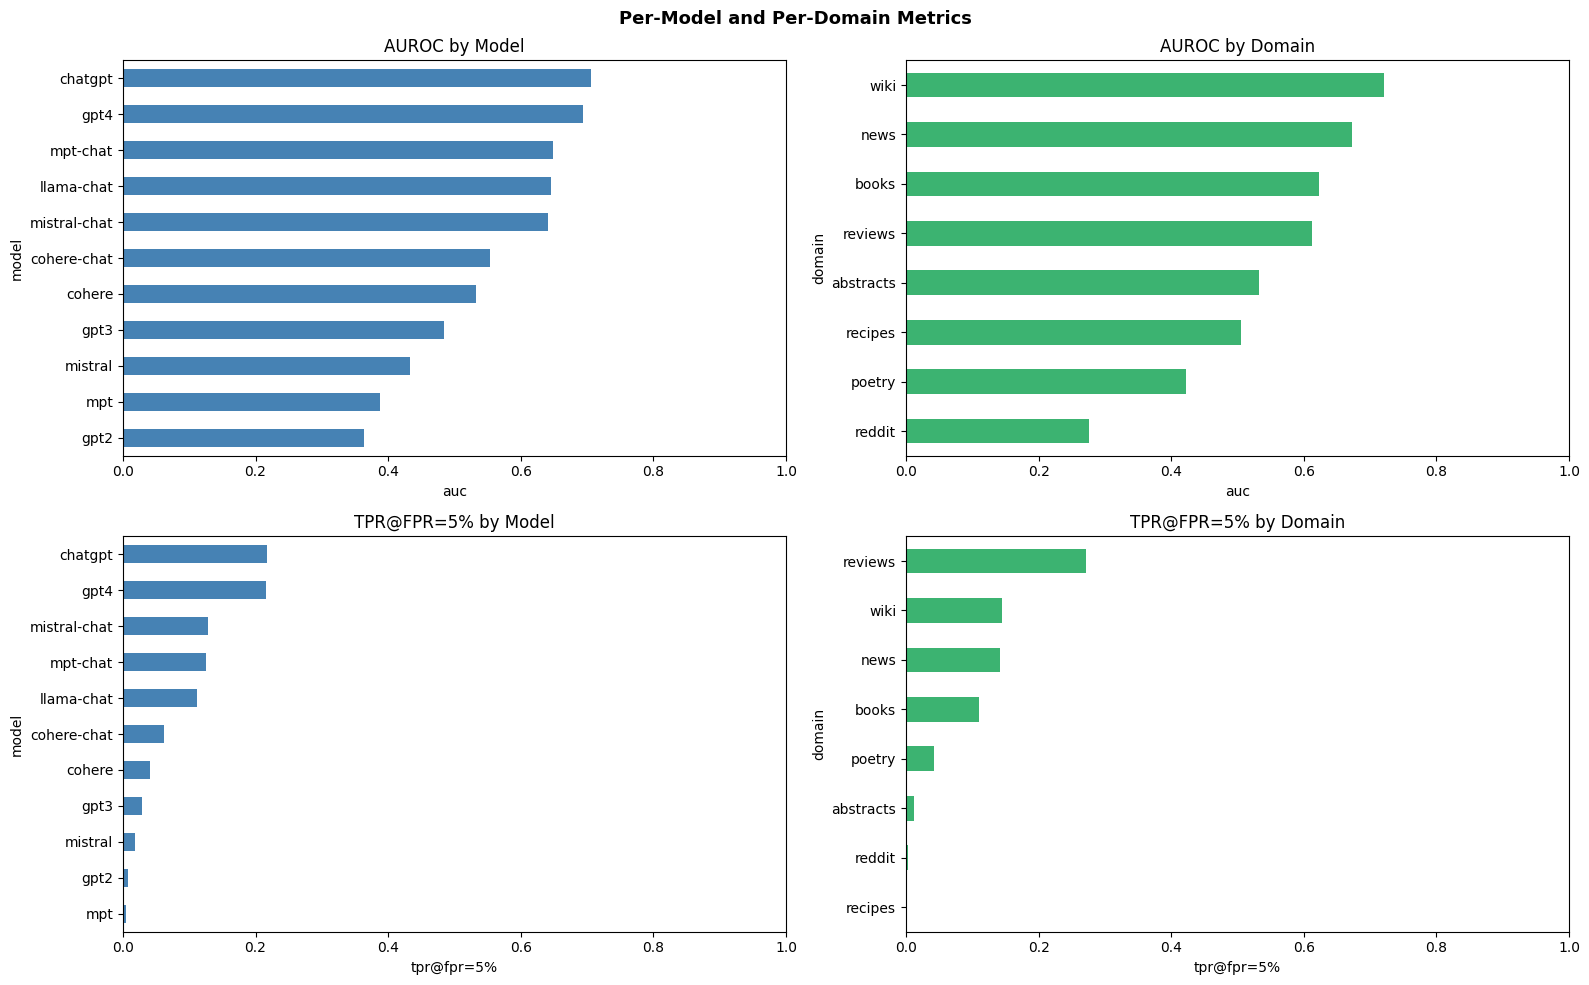

In [11]:
# ── Figure 3: AUC & TPR bar charts per model and domain ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Per-Model and Per-Domain Metrics', fontsize=13, fontweight='bold')

for ax, data, col, color, title in [
    (axes[0,0], model_metrics,  'auc',        'steelblue',     'AUROC by Model'),
    (axes[0,1], domain_metrics, 'auc',        'mediumseagreen','AUROC by Domain'),
    (axes[1,0], model_metrics,  'tpr@fpr=5%', 'steelblue',     'TPR@FPR=5% by Model'),
    (axes[1,1], domain_metrics, 'tpr@fpr=5%', 'mediumseagreen','TPR@FPR=5% by Domain'),
]:
    data[col].sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(title); ax.set_xlabel(col)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/metric_bars_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

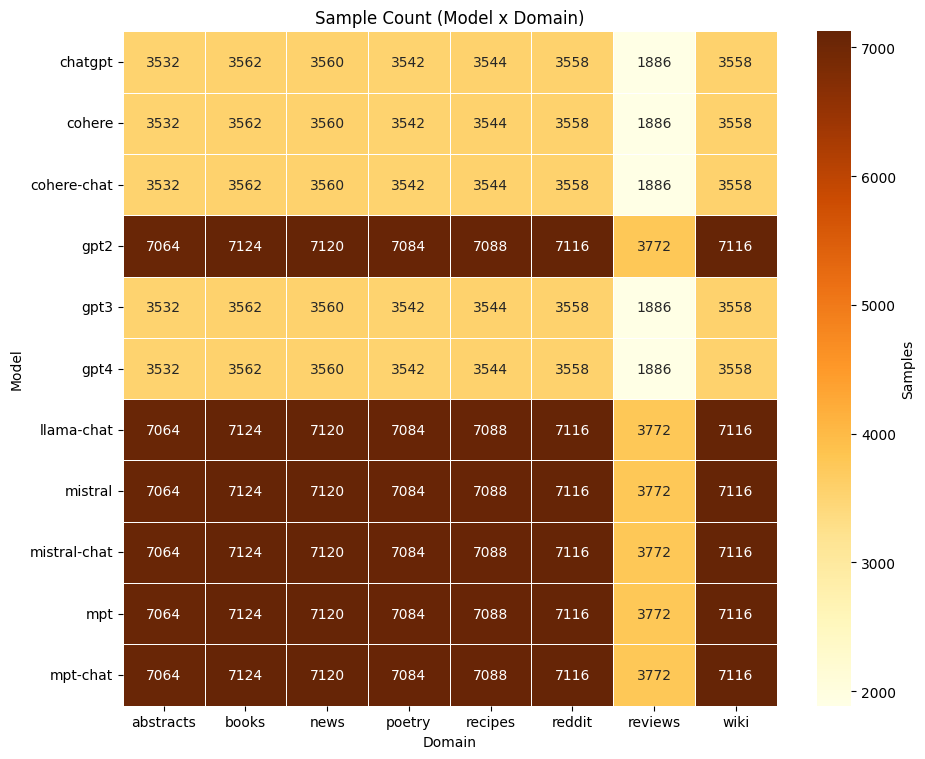

In [12]:
# ── Figure 4: Sample count heatmap ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(n_pivot.columns)*1.2),
                                max(5, len(n_pivot)*0.7)))
sns.heatmap(n_pivot, annot=True, fmt='d', cmap='YlOrBr',
            linewidths=0.4, ax=ax, cbar_kws={'label':'Samples'})
ax.set_title('Sample Count (Model x Domain)')
ax.set_xlabel('Domain'); ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/sample_counts.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Save Fixed Metrics

In [13]:
model_metrics.round(4).to_csv(f'{OUT_DIR}/metrics_by_model_fixed.csv')
domain_metrics.round(4).to_csv(f'{OUT_DIR}/metrics_by_domain_fixed.csv')
auc_pivot.round(4).to_csv(f'{OUT_DIR}/auc_model_x_domain_fixed.csv')
f1_pivot.round(4).to_csv(f'{OUT_DIR}/f1_model_x_domain_fixed.csv')
tpr5_pivot.round(4).to_csv(f'{OUT_DIR}/tpr5_model_x_domain_fixed.csv')

pd.DataFrame([{
    'accuracy': accuracy_score(true_labels, preds),
    'f1_binary': f1, 'roc_auc': auc,
    'tpr@fpr=5%': tpr5, 'tpr@fpr=1%': tpr1,
    'optimal_threshold': optimal_threshold,
    'f1_tuned': f1_t, 'roc_auc_tuned': auc_t,
    'tpr@fpr=5%_tuned': tpr5_t, 'tpr@fpr=1%_tuned': tpr1_t,
}]).to_csv(f'{OUT_DIR}/summary_fixed.csv', index=False)

print(f"All fixed outputs saved to {OUT_DIR}")
print("Done v")

All fixed outputs saved to /content/drive/MyDrive/minor prj temp/raid_results
Done v
